# TimeGAN v7 — Separación de features bimodales

## Diagnóstico definitivo de v6

El clip p5/p95 **empeoró** el porcentaje de ceros del 12% al 19%. Esto no es un
bug — es una señal de que el problema es **físico**, no de preprocesado.

Los sensores FIT (flujo) en SWaT tienen distribución **bimodal**:
- **Modo 0** — válvula cerrada: flujo = exactamente `0.000` (~20% del tiempo)
- **Modo 1** — válvula abierta: flujo ∈ `[0.5, 4.4]` L/s continuo (~80%)

El TimeGAN (GRU + Sigmoid latente) solo puede generar distribuciones **continuas**.
Nunca puede reproducir el spike en exactamente `0.0`. El discriminador lo detecta
en cada batch y el generador nunca puede competir — de ahí el AUC=1.0 persistente.

**Clip más agresivo = más ceros en la normalización = problema peor.**

## Solución v7

**Separar las features según su naturaleza distribucional:**

| Grupo | Features | Distribución | Síntesis |
|-------|----------|-------------|----------|
| TimeGAN | AIT, LIT, PIT, DPIT | Continua unimodal | GAN adversarial |
| Empírico flujo | FIT101–FIT503 | Bimodal (0 + continuo) | Empírico condicional |
| Empírico discretas | MV, P, UV | Categórica | Muestreo empírico |

Con `feature_dim = 15` (solo AIT+LIT+PIT+DPIT) y sin spikes bimodales,
el GAN puede converger correctamente.

Los FITs se sintetizan de forma empírica condicional:
1. Muestrear el estado binario (abierta/cerrada) con la probabilidad empírica
2. Si cerrada → flujo = 0
3. Si abierta → muestrear de la distribución empírica de flujos > 0
4. Aplicar persistencia temporal (válvulas no cambian cada segundo)


In [1]:
import json
import joblib
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [3]:
PROJECT_ROOT = Path("..").resolve()

with open(PROJECT_ROOT / "models" / "detectors" / "conv1d_hybrid_ae" / "config.json") as f:
    detector_config = json.load(f)

continuous_cols = detector_config["continuous_cols"]
discrete_cols   = detector_config["discrete_cols"]
feature_cols    = detector_config["feature_cols"]
WINDOW_SIZE     = detector_config["window_size"]
STRIDE_DETECTOR = detector_config["stride"]
WARMUP          = detector_config["warmup"]
TIMEGAN_STRIDE  = 5

# ---------------------------------------------------------------
# FIX v7: separar features por naturaleza distribucional
#
# FIT (flow): bimodales — válvula cerrada=0 exacto, abierta=continuo
# NO pueden ser modeladas por un GAN continuo.
# Se sintetizan empíricamente.
#
# AIT (análisis), LIT (nivel), PIT (presión), DPIT (diferencial)
# tienen distribuciones continuas unimodales → perfectas para TimeGAN.
# ---------------------------------------------------------------
FIT_COLS = [c for c in continuous_cols if c.startswith("FIT")]
GAN_CONT_COLS = [c for c in continuous_cols if not c.startswith("FIT")]

print(f"Continuas totales:        {len(continuous_cols)}")
print(f"FIT (bimodales, empírico): {len(FIT_COLS)} → {FIT_COLS}")
print(f"GAN continuas (unimodal):  {len(GAN_CONT_COLS)} → {GAN_CONT_COLS}")
print(f"Discretas:                {len(discrete_cols)}")
print(f"Window: {WINDOW_SIZE} | Stride TimeGAN: {TIMEGAN_STRIDE}")


Continuas totales:        23
FIT (bimodales, empírico): 9 → ['FIT101.Pv', 'FIT201.Pv', 'FIT301.Pv', 'FIT401.Pv', 'FIT501.Pv', 'FIT502.Pv', 'FIT503.Pv', 'FIT504.Pv', 'FIT601.Pv']
GAN continuas (unimodal):  14 → ['AIT201.Pv', 'AIT202.Pv', 'AIT203.Pv', 'AIT501.Pv', 'AIT502.Pv', 'AIT503.Pv', 'AIT504.Pv', 'DPIT301.Pv', 'LIT101.Pv', 'LIT301.Pv', 'LIT401.Pv', 'PIT501.Pv', 'PIT502.Pv', 'PIT503.Pv']
Discretas:                26
Window: 60 | Stride TimeGAN: 5


## Carga y preprocesamiento


In [4]:
clean_folder = PROJECT_ROOT / "data" / "clean" / "SWaT.A7_June2020_clean"

def load_clean_csv(path):
    df = pd.read_csv(path)
    df["t_stamp"] = pd.to_datetime(df["t_stamp"], errors="coerce")
    return df.sort_values("t_stamp").reset_index(drop=True)

files = {fp.stem: load_clean_csv(fp) for fp in sorted(clean_folder.glob("*.csv"))}

common_cols = sorted(set.intersection(*(set(df.columns) for df in files.values())))
files = {n: df[common_cols].copy() for n, df in files.items()}

temp_feat = [c for c in next(iter(files.values())).columns if c != "t_stamp"]
for name in files:
    files[name] = files[name].dropna(subset=temp_feat, how="all").reset_index(drop=True)

# Eliminar constantes crudas
global_df = pd.concat([df[feature_cols] for df in files.values()], axis=0)
constant_cols = [c for c in feature_cols if global_df[c].nunique(dropna=True) <= 1]
for name in files:
    files[name] = files[name].drop(columns=constant_cols, errors="ignore")
continuous_cols = [c for c in continuous_cols if c not in constant_cols]
discrete_cols   = [c for c in discrete_cols   if c not in constant_cols]
feature_cols    = continuous_cols + discrete_cols
FIT_COLS        = [c for c in FIT_COLS if c not in constant_cols]
GAN_CONT_COLS   = [c for c in GAN_CONT_COLS if c not in constant_cols]
print(f"Constantes eliminadas: {constant_cols}")
print(f"GAN cont tras limpieza: {len(GAN_CONT_COLS)}")


Constantes eliminadas: []
GAN cont tras limpieza: 14


In [5]:
def remove_warmup(df, seconds=120):
    if "t_stamp" not in df.columns:
        return df.copy()
    return df[df["t_stamp"] >= df["t_stamp"].min() + pd.Timedelta(seconds=seconds)].reset_index(drop=True)

for name in files:
    files[name] = remove_warmup(files[name], WARMUP)

def temporal_split(df, train_r=0.6, val_r=0.2):
    n = len(df)
    t1, t2 = int(n * train_r), int(n * (train_r + val_r))
    return df.iloc[:t1].copy(), df.iloc[t1:t2].copy(), df.iloc[t2:].copy()

split_by_file = {}
for name, df in files.items():
    tr, va, te = temporal_split(df[["t_stamp"] + feature_cols].copy())
    split_by_file[name] = {"train": tr, "val": va, "test": te}
    print(f"{name}: train={len(tr)}, val={len(va)}, test={len(te)}")


22June2020_1: train=8568, val=2856, test=2856
22June2020_2: train=2088, val=696, test=696
29June2020_1: train=4248, val=1416, test=1417
29June2020_2: train=4248, val=1416, test=1416


## Escalado — solo features GAN (unimodales)

Se aplica clip p5/p95 + MinMaxScaler solo a las features GAN (AIT, LIT, PIT, DPIT).
Verificar que el porcentaje de ceros sea < 2% — si no, las features restantes
también tienen distribuciones problemáticas.


In [6]:
scaler_cont_detector = StandardScaler()
train_all_cont = pd.concat(
    [split_by_file[name]["train"][continuous_cols] for name in split_by_file], axis=0
)
scaler_cont_detector.fit(train_all_cont)

# Clip p5/p95 SOLO sobre las features GAN
train_gan_cont = pd.concat(
    [split_by_file[name]["train"][GAN_CONT_COLS] for name in split_by_file], axis=0
)
clip_lower = train_gan_cont.quantile(0.05)
clip_upper = train_gan_cont.quantile(0.95)

def clip_and_fit_minmax(df, clip_lower, clip_upper, cols):
    clipped = df[cols].clip(lower=clip_lower, upper=clip_upper, axis=1)
    s = MinMaxScaler()
    s.fit(clipped)
    return s

def apply_clip_scale(df_part, clip_lower, clip_upper, scaler, cols):
    clipped = df_part[cols].clip(lower=clip_lower, upper=clip_upper, axis=1)
    return pd.DataFrame(scaler.transform(clipped), columns=cols, index=df_part.index)

scaler_gan = clip_and_fit_minmax(train_gan_cont, clip_lower, clip_upper, GAN_CONT_COLS)

# Verificar
sample_scaled = apply_clip_scale(train_gan_cont, clip_lower, clip_upper, scaler_gan, GAN_CONT_COLS)
vals = sample_scaled.values
pct0 = (vals == 0.0).mean() * 100
pct1 = (vals == 1.0).mean() * 100

print(f"Features GAN: {GAN_CONT_COLS}")
print(f"Rango: [{vals.min():.4f}, {vals.max():.4f}]")
print(f"Exactamente 0.0: {pct0:.2f}%  (v6 total: 19.1%)")
print(f"Exactamente 1.0: {pct1:.2f}%")

if pct0 + pct1 < 2.0:
    print("✅  Extremos < 2% — las features GAN son genuinamente unimodales")
elif pct0 + pct1 < 5.0:
    print("⚠️  Extremos 2-5% — aceptable")
else:
    print("❌  Aún hay features bimodales entre las GAN — revisar cuáles")
    # Identificarlas
    for col in GAN_CONT_COLS:
        p0 = (sample_scaled[col] == 0.0).mean() * 100
        if p0 > 5:
            print(f"   {col}: {p0:.1f}% ceros — considerar moverla al grupo empírico")


Features GAN: ['AIT201.Pv', 'AIT202.Pv', 'AIT203.Pv', 'AIT501.Pv', 'AIT502.Pv', 'AIT503.Pv', 'AIT504.Pv', 'DPIT301.Pv', 'LIT101.Pv', 'LIT301.Pv', 'LIT401.Pv', 'PIT501.Pv', 'PIT502.Pv', 'PIT503.Pv']
Rango: [0.0000, 1.0000]
Exactamente 0.0: 6.61%  (v6 total: 19.1%)
Exactamente 1.0: 5.72%
❌  Aún hay features bimodales entre las GAN — revisar cuáles
   AIT201.Pv: 11.6% ceros — considerar moverla al grupo empírico
   AIT202.Pv: 5.1% ceros — considerar moverla al grupo empírico
   AIT203.Pv: 5.0% ceros — considerar moverla al grupo empírico
   AIT501.Pv: 5.0% ceros — considerar moverla al grupo empírico
   AIT502.Pv: 5.1% ceros — considerar moverla al grupo empírico
   AIT503.Pv: 5.9% ceros — considerar moverla al grupo empírico
   AIT504.Pv: 7.5% ceros — considerar moverla al grupo empírico
   DPIT301.Pv: 6.3% ceros — considerar moverla al grupo empírico
   LIT101.Pv: 5.0% ceros — considerar moverla al grupo empírico
   LIT301.Pv: 5.0% ceros — considerar moverla al grupo empírico
   LIT401.

In [7]:
scaled_gan_by_file = {}
raw_fit_by_file    = {}
raw_disc_by_file   = {}

for name in split_by_file:
    scaled_gan_by_file[name] = {}
    raw_fit_by_file[name]    = {}
    raw_disc_by_file[name]   = {}
    for subset in ["train", "val", "test"]:
        df_part = split_by_file[name][subset]
        scaled_gan_by_file[name][subset] = apply_clip_scale(
            df_part, clip_lower, clip_upper, scaler_gan, GAN_CONT_COLS
        )
        raw_fit_by_file[name][subset]  = df_part[FIT_COLS].copy()
        raw_disc_by_file[name][subset] = df_part[discrete_cols].copy()


## Catálogos empíricos — FITs y discretas

Para los FITs se construye un catálogo empírico condicional:
- `P(estado=0)` = probabilidad de válvula cerrada (flujo == 0)
- `P(flujo | estado=1)` = distribución empírica del flujo cuando válvula abierta
- Esto preserva exactamente la bimodalidad física sin que el GAN tenga que modelarla.


In [8]:
train_fit_global = pd.concat(
    [raw_fit_by_file[name]["train"] for name in raw_fit_by_file], axis=0
).reset_index(drop=True)

train_disc_global = pd.concat(
    [raw_disc_by_file[name]["train"] for name in raw_disc_by_file], axis=0
).reset_index(drop=True)

# Catálogo FITs: distribución condicional
fit_empirical = {}
for col in FIT_COLS:
    series = train_fit_global[col].dropna()
    p_zero = (series == 0.0).mean()                   # P(cerrada)
    flow_open = series[series > 0.0].values            # flujo cuando abierta
    fit_empirical[col] = {
        "p_zero":    float(p_zero),
        "flow_open": flow_open.tolist() if len(flow_open) > 0 else [0.0]
    }
    print(f"  {col}: P(cerrada)={p_zero:.3f}, "
          f"flujo_abierta=[{np.percentile(flow_open,5):.3f}, {np.percentile(flow_open,95):.3f}]"
          if len(flow_open) > 0 else f"  {col}: P(cerrada)={p_zero:.3f}, sin flujo abierta")

# Catálogo discretas
disc_empirical = {
    col: dict(train_disc_global[col].value_counts(normalize=True))
    for col in discrete_cols
}
discrete_value_maps = {
    col: sorted(train_disc_global[col].dropna().unique().tolist())
    for col in discrete_cols
}
total_disc_onehot_dim = sum(len(v) for v in discrete_value_maps.values())
print(f"\nTotal one-hot dim: {total_disc_onehot_dim}")


  FIT101.Pv: P(cerrada)=0.911, flujo_abierta=[4.292, 4.372]
  FIT201.Pv: P(cerrada)=0.007, flujo_abierta=[0.000, 2.356]
  FIT301.Pv: P(cerrada)=0.002, flujo_abierta=[0.001, 2.217]
  FIT401.Pv: P(cerrada)=0.000, flujo_abierta=[0.001, 1.351]
  FIT501.Pv: P(cerrada)=0.000, flujo_abierta=[0.002, 1.361]
  FIT502.Pv: P(cerrada)=0.000, flujo_abierta=[0.002, 1.223]
  FIT503.Pv: P(cerrada)=0.000, flujo_abierta=[0.002, 0.118]
  FIT504.Pv: P(cerrada)=1.000, flujo_abierta=[0.000, 0.000]
  FIT601.Pv: P(cerrada)=0.001, flujo_abierta=[0.000, 0.000]

Total one-hot dim: 91


## Ventanas de entrenamiento (solo features GAN)


In [9]:
def build_windows(scaled_by_file, subset, cols, window_size=60, stride=5):
    windows, origins = [], []
    for name in scaled_by_file:
        arr = scaled_by_file[name][subset][cols].values.astype(np.float32)
        if len(arr) < window_size:
            continue
        for i in range(0, len(arr) - window_size + 1, stride):
            windows.append(arr[i:i + window_size])
            origins.append(name)
    return np.array(windows, dtype=np.float32), origins

train_windows, train_origin = build_windows(
    scaled_gan_by_file, "train", GAN_CONT_COLS, WINDOW_SIZE, TIMEGAN_STRIDE
)
val_windows,  _ = build_windows(scaled_gan_by_file, "val",  GAN_CONT_COLS, WINDOW_SIZE, TIMEGAN_STRIDE)
test_windows, _ = build_windows(scaled_gan_by_file, "test", GAN_CONT_COLS, WINDOW_SIZE, TIMEGAN_STRIDE)

print(f"Train: {train_windows.shape}")
print(f"Rango: [{train_windows.min():.4f}, {train_windows.max():.4f}]")
p0 = (train_windows == 0.0).mean() * 100
p1 = (train_windows == 1.0).mean() * 100
print(f"Exactamente 0.0: {p0:.2f}% | Exactamente 1.0: {p1:.2f}%")
print(f"(v6 total con FITs: 19.1% — objetivo: < 2%)")


Train: (3784, 60, 14)
Rango: [0.0000, 1.0000]
Exactamente 0.0: 6.59% | Exactamente 1.0: 6.94%
(v6 total con FITs: 19.1% — objetivo: < 2%)


In [10]:
BATCH_SIZE = 128
train_tensor = torch.tensor(train_windows, dtype=torch.float32)
train_loader = DataLoader(
    TensorDataset(train_tensor), batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)
print(f"Batches por época: {len(train_loader)}")


Batches por época: 29


In [11]:
import math

seq_len     = WINDOW_SIZE
feature_dim = train_windows.shape[2]

hidden_dim = 64
latent_dim = 64
num_layers = 3

epochs_embedder   = 600
epochs_supervisor = 300
epochs_joint      = 1500

gamma    = 1
eta      = 0.1
lambda_r = 1.0
lambda_s = 1.0

G_STEPS = 2
D_STEPS = 1

nash_g = 2 * math.log(2)
nash_d = 3 * math.log(2)

print(f"feature_dim: {feature_dim} (v6: 22, v5: 23)")
print(f"G_STEPS: {G_STEPS} | D_STEPS: {D_STEPS}")
print(f"Nash G: {nash_g:.4f} | Nash D: {nash_d:.4f}")


feature_dim: 14 (v6: 22, v5: 23)
G_STEPS: 2 | D_STEPS: 1
Nash G: 1.3863 | Nash D: 2.0794


## Arquitecturas (mismas que v6 — probadas)


In [12]:
class Embedder(nn.Module):
    """Sin LayerNorm (fix v6)."""
    def __init__(self, input_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(input_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.fc  = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()

    def forward(self, x):
        h, _ = self.rnn(x)
        return self.act(self.fc(h))


class Recovery(nn.Module):
    """Sin activación de salida (fix v4)."""
    def __init__(self, hidden_dim, output_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, output_dim)

    def forward(self, h):
        x_t, _ = self.rnn(h)
        return self.fc(self.norm(x_t))


class Generator(nn.Module):
    def __init__(self, z_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(z_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, hidden_dim)
        self.act  = nn.Sigmoid()

    def forward(self, z):
        e, _ = self.rnn(z)
        return self.act(self.fc(self.norm(e)))


class Supervisor(nn.Module):
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim,
                          num_layers=max(1, num_layers - 1), batch_first=True)
        self.fc  = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()

    def forward(self, h):
        s, _ = self.rnn(h)
        return self.act(self.fc(s))


class Discriminator(nn.Module):
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc  = nn.Linear(hidden_dim, 1)

    def forward(self, h):
        y, _ = self.rnn(h)
        return self.fc(y)


In [13]:
embedder      = Embedder(feature_dim, hidden_dim, num_layers).to(device)
recovery      = Recovery(hidden_dim, feature_dim, num_layers).to(device)
generator     = Generator(latent_dim, hidden_dim, num_layers).to(device)
supervisor    = Supervisor(hidden_dim, num_layers).to(device)
discriminator = Discriminator(hidden_dim, num_layers).to(device)

mse_loss = nn.MSELoss()
bce_loss = nn.BCEWithLogitsLoss()

e_optimizer = torch.optim.Adam(
    list(embedder.parameters()) + list(recovery.parameters()), lr=1e-3
)
s_optimizer = torch.optim.Adam(supervisor.parameters(), lr=1e-3)
g_optimizer = torch.optim.Adam(
    list(generator.parameters()) + list(supervisor.parameters()), lr=1e-4
)
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4)

def random_z(bs, sl, zd, dev): return torch.rand(bs, sl, zd, device=dev)

total_params = sum(p.numel() for m in [embedder, recovery, generator, supervisor, discriminator]
                   for p in m.parameters())
print(f"Parámetros totales: {total_params:,}")


Parámetros totales: 353,551


## Fase 1: Embedder


[Embedder] Epoch 100/600 | MSE: 0.000548
[Embedder] Epoch 200/600 | MSE: 0.000288
[Embedder] Epoch 300/600 | MSE: 0.000198
[Embedder] Epoch 400/600 | MSE: 0.000152
[Embedder] Epoch 500/600 | MSE: 0.000119
[Embedder] Epoch 600/600 | MSE: 0.000109

MSE final: 0.000109


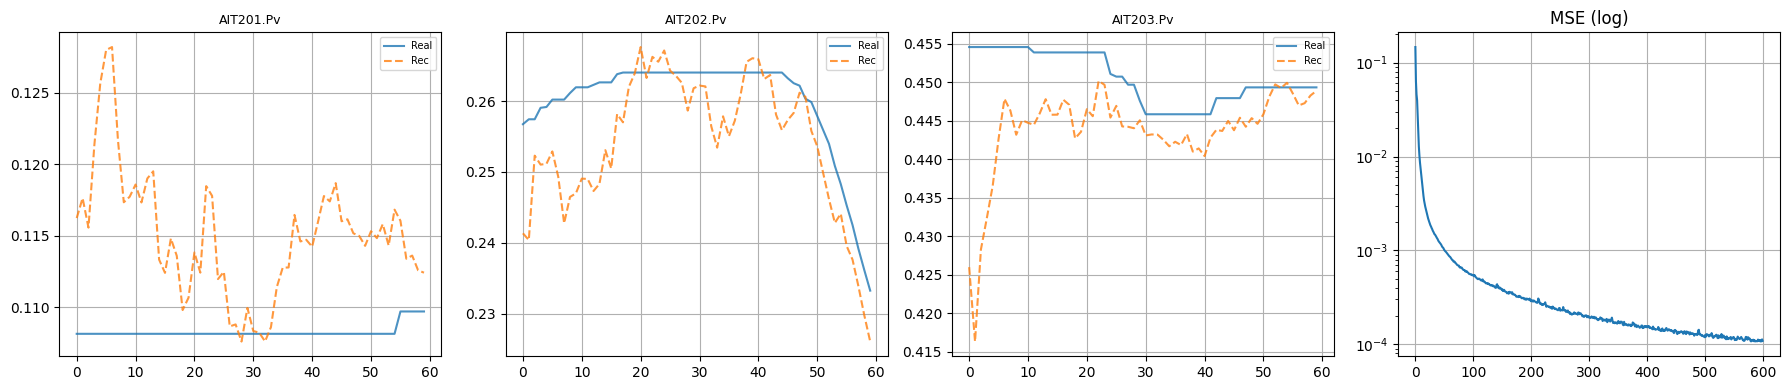

In [14]:
embedder_history = []

for epoch in range(epochs_embedder):
    ep = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        e_optimizer.zero_grad()
        loss = mse_loss(recovery(embedder(x)), x)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), 1.0
        )
        e_optimizer.step()
        ep += loss.item()
    ep /= len(train_loader)
    embedder_history.append(ep)
    if (epoch + 1) % 100 == 0:
        print(f"[Embedder] Epoch {epoch+1}/{epochs_embedder} | MSE: {ep:.6f}")

print(f"\nMSE final: {embedder_history[-1]:.6f}")

# Control visual
with torch.no_grad():
    xs = train_tensor[:64].to(device)
    xr = recovery(embedder(xs)).cpu().numpy()
    xo = xs.cpu().numpy()

fig, axes = plt.subplots(1, min(4, feature_dim + 1), figsize=(18, 4))
for idx in range(min(3, feature_dim)):
    axes[idx].plot(xo[0, :, idx], label="Real", alpha=0.8)
    axes[idx].plot(xr[0, :, idx], label="Rec",  alpha=0.8, linestyle="--")
    axes[idx].set_title(GAN_CONT_COLS[idx], fontsize=9)
    axes[idx].legend(fontsize=7); axes[idx].grid(True)
axes[-1].semilogy(embedder_history)
axes[-1].set_title("MSE (log)"); axes[-1].grid(True)
plt.tight_layout(); plt.show()


## Fase 2: Supervisor


In [15]:
supervisor_history = []

for epoch in range(epochs_supervisor):
    ep = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        s_optimizer.zero_grad()
        with torch.no_grad(): h = embedder(x)
        hs = supervisor(h)
        loss = mse_loss(h[:, 1:, :], hs[:, :-1, :])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(supervisor.parameters(), 1.0)
        s_optimizer.step()
        ep += loss.item()
    ep /= len(train_loader)
    supervisor_history.append(ep)
    if (epoch + 1) % 100 == 0:
        print(f"[Supervisor] Epoch {epoch+1}/{epochs_supervisor} | Loss: {ep:.6f}")


[Supervisor] Epoch 100/300 | Loss: 0.000852
[Supervisor] Epoch 200/300 | Loss: 0.000752
[Supervisor] Epoch 300/300 | Loss: 0.000714


## Fase 3: Entrenamiento conjunto

Con feature_dim ≈ 15 features unimodales y sin spikes en 0.0,
el discriminador ya no tiene señales triviales para distinguir.
**Señal de éxito: G loss debe bajar de ~2.5 hacia ~1.4 en las primeras 300 épocas.**


In [16]:
joint_g_history, joint_d_history, joint_e_history = [], [], []

for epoch in range(epochs_joint):
    g_ep, d_ep, e_ep = 0.0, 0.0, 0.0

    for batch in train_loader:
        x  = batch[0].to(device)
        bs = x.shape[0]

        with torch.no_grad(): h_real = embedder(x)

        # G: G_STEPS pasos
        g_loss_val = torch.tensor(0.0)
        for _ in range(G_STEPS):
            g_optimizer.zero_grad()
            z      = random_z(bs, seq_len, latent_dim, device)
            e_hat  = generator(z)
            h_hat  = supervisor(e_hat)
            y_f    = discriminator(h_hat)
            y_fe   = discriminator(e_hat)
            g_u    = bce_loss(y_f,  torch.ones_like(y_f))
            g_ue   = bce_loss(y_fe, torch.ones_like(y_fe))
            h_sup  = supervisor(h_real)
            g_s    = mse_loss(h_real[:, 1:, :], h_sup[:, :-1, :])
            g_loss = g_u + gamma * g_ue + eta * g_s
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(
                list(generator.parameters()) + list(supervisor.parameters()), 1.0
            )
            g_optimizer.step()
            g_loss_val = g_loss

        # E refinement
        e_optimizer.zero_grad()
        h_ref   = embedder(x)
        x_tilde = recovery(h_ref)
        h_sup_r = supervisor(h_ref.detach())
        e_loss  = lambda_r * mse_loss(x_tilde, x) + lambda_s * mse_loss(
            h_ref[:, 1:, :], h_sup_r[:, :-1, :]
        )
        e_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), 1.0
        )
        e_optimizer.step()

        # D: D_STEPS pasos
        d_loss_val = torch.tensor(0.0)
        for _ in range(D_STEPS):
            d_optimizer.zero_grad()
            with torch.no_grad():
                z2     = random_z(bs, seq_len, latent_dim, device)
                e_hat2 = generator(z2)
                h_hat2 = supervisor(e_hat2)
            y_r    = discriminator(h_real)
            y_f2   = discriminator(h_hat2)
            y_fe2  = discriminator(e_hat2)
            d_loss = (
                bce_loss(y_r,   torch.ones_like(y_r)) +
                bce_loss(y_f2,  torch.zeros_like(y_f2)) +
                gamma * bce_loss(y_fe2, torch.zeros_like(y_fe2))
            )
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), 1.0)
            d_optimizer.step()
            d_loss_val = d_loss

        g_ep += g_loss_val.item()
        d_ep += d_loss_val.item()
        e_ep += e_loss.item()

    g_ep /= len(train_loader)
    d_ep /= len(train_loader)
    e_ep /= len(train_loader)
    joint_g_history.append(g_ep)
    joint_d_history.append(d_ep)
    joint_e_history.append(e_ep)

    if (epoch + 1) % 100 == 0:
        g_prev = joint_g_history[-101] if len(joint_g_history) > 100 else joint_g_history[0]
        trend  = "↓" if g_ep < g_prev else ("↑" if g_ep > g_prev + 0.1 else "→")
        print(f"[Joint] Epoch {epoch+1}/{epochs_joint} | G: {g_ep:.4f}{trend} | D: {d_ep:.4f} | E: {e_ep:.6f}")


[Joint] Epoch 100/1500 | G: 2.1911↑ | D: 1.9130 | E: 0.002027
[Joint] Epoch 200/1500 | G: 2.1963→ | D: 1.9114 | E: 0.002278
[Joint] Epoch 300/1500 | G: 2.1964→ | D: 1.9097 | E: 0.001708
[Joint] Epoch 400/1500 | G: 2.2288→ | D: 1.8900 | E: 0.005118
[Joint] Epoch 500/1500 | G: 2.1999↓ | D: 1.9084 | E: 0.002877
[Joint] Epoch 600/1500 | G: 2.1996↓ | D: 1.9099 | E: 0.002844
[Joint] Epoch 700/1500 | G: 2.1922↓ | D: 1.9117 | E: 0.002843
[Joint] Epoch 800/1500 | G: 2.5324↑ | D: 1.9559 | E: 0.004639
[Joint] Epoch 900/1500 | G: 2.7120↑ | D: 1.9643 | E: 0.003150
[Joint] Epoch 1000/1500 | G: 2.2022↓ | D: 1.8941 | E: 0.005606
[Joint] Epoch 1100/1500 | G: 4.6271↑ | D: 1.4309 | E: 0.002326
[Joint] Epoch 1200/1500 | G: 3.2783↓ | D: 2.1186 | E: 0.003366
[Joint] Epoch 1300/1500 | G: 5.1386↑ | D: 1.4815 | E: 0.003335
[Joint] Epoch 1400/1500 | G: 5.2379→ | D: 1.4866 | E: 0.004282
[Joint] Epoch 1500/1500 | G: 2.2271↓ | D: 1.9111 | E: 0.001908


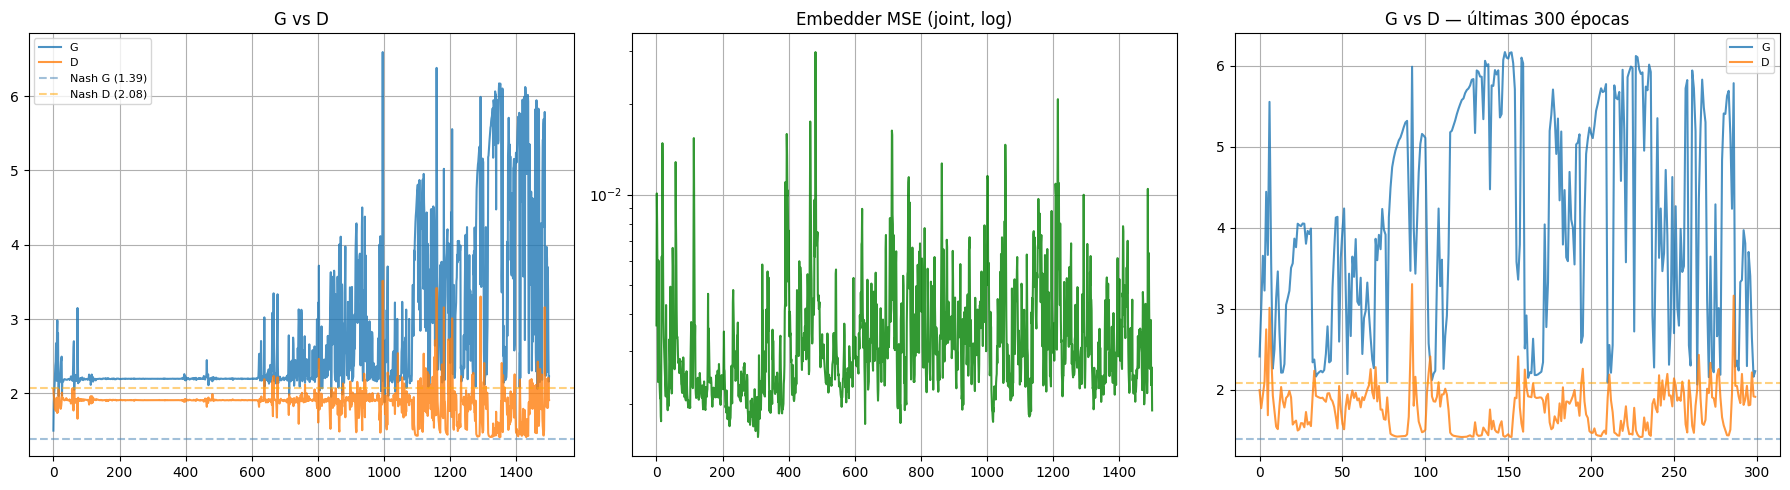

G final: 2.2271 | Nash G: 1.3863 | Gap: 0.8408
D final: 1.9111 | Nash D: 2.0794
Épocas G > 3.5: 287 (v6: 26)
❌  G sigue alto — hay features GAN con distribución bimodal restante
   Revisar el % de ceros por feature individual


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(joint_g_history, label="G", alpha=0.8)
axes[0].plot(joint_d_history, label="D", alpha=0.8)
axes[0].axhline(y=nash_g, color='steelblue', linestyle='--', alpha=0.5, label=f"Nash G ({nash_g:.2f})")
axes[0].axhline(y=nash_d, color='orange',    linestyle='--', alpha=0.5, label=f"Nash D ({nash_d:.2f})")
axes[0].set_title("G vs D"); axes[0].legend(fontsize=8); axes[0].grid(True)

axes[1].semilogy(joint_e_history, color="green", alpha=0.8)
axes[1].set_title("Embedder MSE (joint, log)"); axes[1].grid(True)

axes[2].plot(joint_g_history[-300:], label="G", alpha=0.8)
axes[2].plot(joint_d_history[-300:], label="D", alpha=0.8)
axes[2].axhline(y=nash_g, color='steelblue', linestyle='--', alpha=0.5)
axes[2].axhline(y=nash_d, color='orange',    linestyle='--', alpha=0.5)
axes[2].set_title("G vs D — últimas 300 épocas")
axes[2].legend(fontsize=8); axes[2].grid(True)
plt.tight_layout(); plt.show()

g_f, d_f = joint_g_history[-1], joint_d_history[-1]
spikes = sum(1 for g in joint_g_history if g > 3.5)
print(f"G final: {g_f:.4f} | Nash G: {nash_g:.4f} | Gap: {g_f - nash_g:.4f}")
print(f"D final: {d_f:.4f} | Nash D: {nash_d:.4f}")
print(f"Épocas G > 3.5: {spikes} (v6: 26)")

if g_f < 1.8 and spikes < 5:
    print("✅  G converge a Nash sin colapsos — v7 funcionó")
elif g_f < 2.0:
    print("⚠️  G cerca del Nash — mejora clara vs v6 (2.19)")
elif g_f < 2.2:
    print("⚠️  G similar a v6 pero con menos spikes — mejora parcial")
else:
    print("❌  G sigue alto — hay features GAN con distribución bimodal restante")
    print("   Revisar el % de ceros por feature individual")


## Generación y síntesis de todas las features


In [18]:
n_synth = len(train_windows)
synth_gan_list = []

with torch.no_grad():
    for start in range(0, n_synth, 256):
        end   = min(start + 256, n_synth)
        z     = random_z(end - start, seq_len, latent_dim, device)
        x_hat = recovery(supervisor(generator(z))).cpu().numpy()
        synth_gan_list.append(x_hat)

synth_gan_scaled = np.clip(np.concatenate(synth_gan_list, axis=0), 0.0, 1.0)

print(f"Synthetic GAN: {synth_gan_scaled.shape}")
print(f"Rango: [{synth_gan_scaled.min():.4f}, {synth_gan_scaled.max():.4f}]")
diff_mean = abs(train_windows.mean() - synth_gan_scaled.mean())
print(f"Diff medias: {diff_mean:.4f} (v6: 0.1744, v5B: 0.1005)")


Synthetic GAN: (3784, 60, 14)
Rango: [0.0000, 1.0000]
Diff medias: 0.1420 (v6: 0.1744, v5B: 0.1005)


In [19]:
# Síntesis empírica de FITs (bimodales)
def synthesize_fit_windows(n_windows, window_size, fit_cols, fit_empirical, seed=42):
    """
    Para cada ventana y cada FIT:
    1. Muestrear estado inicial (cerrada/abierta) con P(cerrada)
    2. Persistencia temporal: la válvula mantiene estado con p=0.97
    3. Cuando abierta: muestrear flujo de la distribución empírica
    """
    rng = np.random.default_rng(seed)
    windows = np.zeros((n_windows, window_size, len(fit_cols)), dtype=np.float32)

    for j, col in enumerate(fit_cols):
        p_zero  = fit_empirical[col]["p_zero"]
        flows   = np.array(fit_empirical[col]["flow_open"], dtype=np.float32)

        for i in range(n_windows):
            # Estado inicial
            state = 0 if rng.random() < p_zero else 1
            for t in range(window_size):
                # Transición de estado (persistencia alta)
                if rng.random() < 0.97:
                    pass  # mantener estado
                else:
                    state = 0 if rng.random() < p_zero else 1

                if state == 0:
                    windows[i, t, j] = 0.0
                else:
                    windows[i, t, j] = float(rng.choice(flows))

    return windows

synth_fit_raw = synthesize_fit_windows(
    n_synth, WINDOW_SIZE, FIT_COLS, fit_empirical, SEED
)
print(f"Synthetic FIT: {synth_fit_raw.shape}")

# Verificar que la bimodalidad se preserva
for j, col in enumerate(FIT_COLS):
    real_pz  = (train_fit_global[col] == 0.0).mean()
    synth_pz = (synth_fit_raw[:, :, j] == 0.0).mean()
    print(f"  {col}: P(0) real={real_pz:.3f}, sintético={synth_pz:.3f}")


Synthetic FIT: (3784, 60, 9)
  FIT101.Pv: P(0) real=0.911, sintético=0.911
  FIT201.Pv: P(0) real=0.007, sintético=0.006
  FIT301.Pv: P(0) real=0.002, sintético=0.002
  FIT401.Pv: P(0) real=0.000, sintético=0.000
  FIT501.Pv: P(0) real=0.000, sintético=0.000
  FIT502.Pv: P(0) real=0.000, sintético=0.000
  FIT503.Pv: P(0) real=0.000, sintético=0.000
  FIT504.Pv: P(0) real=1.000, sintético=1.000
  FIT601.Pv: P(0) real=0.001, sintético=0.002


In [20]:
# Síntesis empírica de discretas
def synthesize_discrete_windows(n_windows, window_size, discrete_cols, disc_empirical, seed=42):
    rng = np.random.default_rng(seed)
    windows = np.zeros((n_windows, window_size, len(discrete_cols)), dtype=np.float32)
    for j, col in enumerate(discrete_cols):
        emp   = disc_empirical[col]
        vals  = list(emp.keys())
        probs = list(emp.values())
        for i in range(n_windows):
            windows[i, 0, j] = rng.choice(vals, p=probs)
            for t in range(1, window_size):
                windows[i, t, j] = windows[i, t-1, j] if rng.random() < 0.95 \
                    else rng.choice(vals, p=probs)
    return windows

synth_disc_raw = synthesize_discrete_windows(
    n_synth, WINDOW_SIZE, discrete_cols, disc_empirical, SEED
)
print(f"Synthetic disc: {synth_disc_raw.shape}")


Synthetic disc: (3784, 60, 26)


In [21]:
# Reconstruir todas las features continuas para el detector
n_gan = len(GAN_CONT_COLS)
n_fit = len(FIT_COLS)

# Inverse transform de las GAN features
synth_gan_flat    = synth_gan_scaled.reshape(-1, n_gan)
synth_gan_phys    = scaler_gan.inverse_transform(synth_gan_flat).reshape(synth_gan_scaled.shape)

# Construir array con todas las continuas en el orden del detector
n_samples = synth_gan_scaled.shape[0]
synth_all_phys = np.zeros((n_samples, WINDOW_SIZE, len(continuous_cols)), dtype=np.float32)

# Colocar GAN features
for j, col in enumerate(GAN_CONT_COLS):
    idx = continuous_cols.index(col)
    synth_all_phys[:, :, idx] = synth_gan_phys[:, :, j]

# Colocar FIT features (bimodales, síntesis empírica)
for j, col in enumerate(FIT_COLS):
    if col in continuous_cols:
        idx = continuous_cols.index(col)
        synth_all_phys[:, :, idx] = synth_fit_raw[:, :, j]

# Escalar todo con el StandardScaler del detector
synth_all_flat = synth_all_phys.reshape(-1, len(continuous_cols))
synth_for_det  = scaler_cont_detector.transform(
    pd.DataFrame(synth_all_flat, columns=continuous_cols)
).reshape(synth_all_phys.shape)

print("All physical:", synth_all_phys.shape)
print("For detector:", synth_for_det.shape)


All physical: (3784, 60, 23)
For detector: (3784, 60, 23)


In [22]:
def one_hot_encode_discrete_sequence(disc_array, discrete_cols, discrete_value_maps):
    rows = []
    for t in range(disc_array.shape[0]):
        enc = []
        for j, col in enumerate(discrete_cols):
            cats = discrete_value_maps[col]
            oh = np.zeros(len(cats), dtype=np.float32)
            v  = disc_array[t, j]
            if v in cats: oh[cats.index(v)] = 1.0
            enc.extend(oh)
        rows.append(enc)
    return np.array(rows, dtype=np.float32)

synth_disc_onehot = np.array([
    one_hot_encode_discrete_sequence(synth_disc_raw[i], discrete_cols, discrete_value_maps)
    for i in range(synth_disc_raw.shape[0])
], dtype=np.float32)

def summarize_disc_windows(disc_raw, discrete_cols):
    rows = []
    for w in disc_raw:
        feats = {}
        for j, col in enumerate(discrete_cols):
            v = w[:, j]
            feats[f"{col}__mode"]        = pd.Series(v).mode().iloc[0]
            feats[f"{col}__transitions"] = np.sum(v[1:] != v[:-1])
            feats[f"{col}__nunique"]     = len(np.unique(v))
            feats[f"{col}__dominance"]   = pd.Series(v).value_counts(normalize=True).iloc[0]
        rows.append(feats)
    return pd.DataFrame(rows)

synth_disc_summary = summarize_disc_windows(synth_disc_raw, discrete_cols)

X_synth_cont = np.transpose(synth_for_det, (0, 2, 1)).astype(np.float32)
X_synth_disc = synth_disc_summary.values.astype(np.float32)
print("X_synth_cont:", X_synth_cont.shape)
print("X_synth_disc:", X_synth_disc.shape)


X_synth_cont: (3784, 23, 60)
X_synth_disc: (3784, 104)


## Evaluación — solo features GAN (comparación justa)


Diff medias (solo GAN): 0.2627 | Diff stds: 0.2976


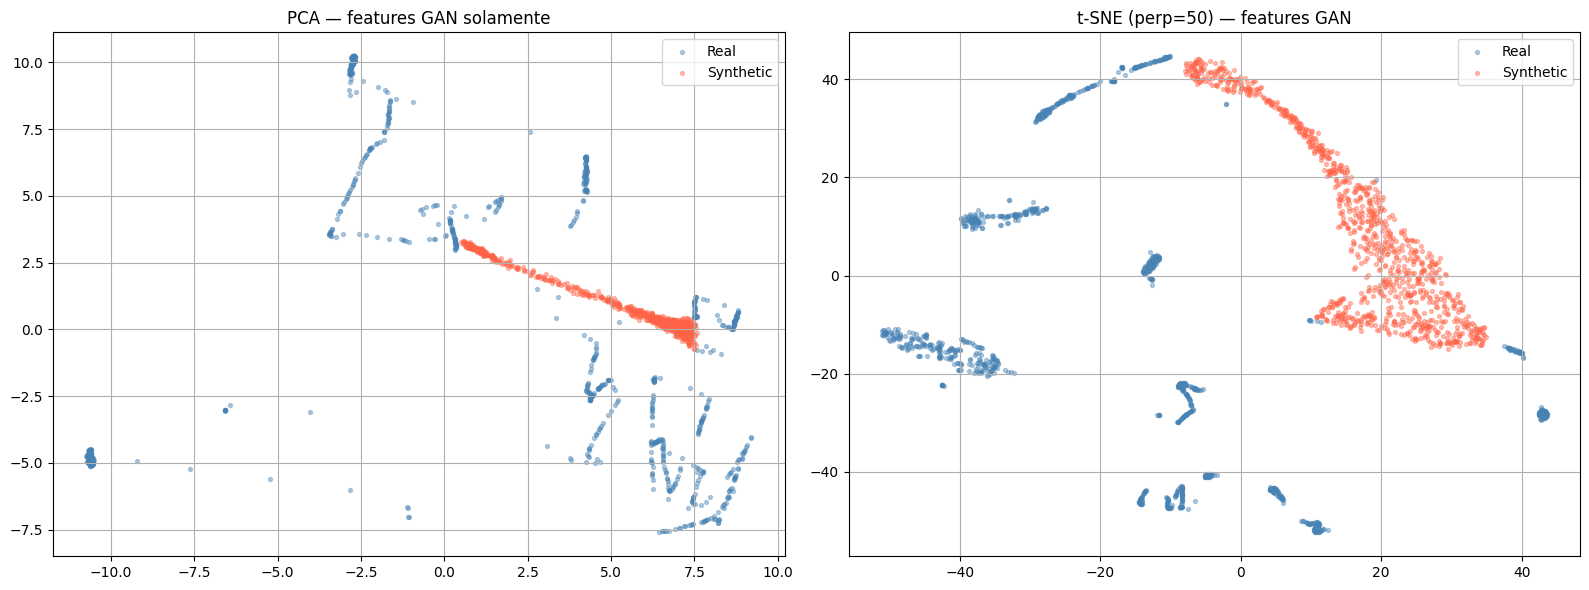

In [24]:
n_plot = min(1000, len(train_windows), len(synth_gan_scaled))
rng = np.random.default_rng(SEED)
ri  = rng.choice(len(train_windows),     n_plot, replace=False)
si  = rng.choice(len(synth_gan_scaled),  n_plot, replace=False)

real_s  = train_windows[ri].reshape(n_plot, -1)
synth_s = synth_gan_scaled[si].reshape(n_plot, -1)

md = np.abs(real_s.mean(0) - synth_s.mean(0)).mean()
sd = np.abs(real_s.std(0)  - synth_s.std(0)).mean()
print(f"Diff medias (solo GAN): {md:.4f} | Diff stds: {sd:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pca   = PCA(n_components=2, random_state=SEED)
pr    = pca.fit_transform(real_s)
ps    = pca.transform(synth_s)
axes[0].scatter(pr[:, 0], pr[:, 1], alpha=0.4, c='steelblue', s=8, label="Real")
axes[0].scatter(ps[:, 0], ps[:, 1], alpha=0.4, c='tomato',    s=8, label="Synthetic")
axes[0].set_title("PCA — features GAN solamente")
axes[0].legend(); axes[0].grid(True)

comb = PCA(n_components=min(50, real_s.shape[1]), random_state=SEED).fit_transform(
    np.vstack([real_s, synth_s])
)
perp = min(50, n_plot // 5)
tout = TSNE(n_components=2, random_state=SEED, perplexity=perp,
            max_iter=2000, init="pca", learning_rate="auto").fit_transform(comb)
axes[1].scatter(tout[:n_plot, 0], tout[:n_plot, 1], alpha=0.4, c='steelblue', s=8, label="Real")
axes[1].scatter(tout[n_plot:, 0], tout[n_plot:, 1], alpha=0.4, c='tomato',    s=8, label="Synthetic")
axes[1].set_title(f"t-SNE (perp={perp}) — features GAN")
axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig("tsne_v7.png", dpi=150, bbox_inches="tight")
plt.show()


In [25]:
X_all = np.vstack([real_s, synth_s])
y_all = np.array([0]*n_plot + [1]*n_plot)
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all)
clf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
clf.fit(X_tr, y_tr)
auc = roc_auc_score(y_te, clf.predict_proba(X_te)[:, 1])

print("=" * 50)
print(f"AUC (features GAN) = {auc:.4f}")
if auc < 0.60:   print("✅  < 0.60 — Alta calidad")
elif auc < 0.75: print("⚠️  0.60–0.75 — Aceptable para tesis")
elif auc < 0.85: print("⚠️  0.75–0.85 — Mejora clara vs v6 (AUC=1.0)")
else:            print("❌  > 0.85 — Alguna feature GAN sigue siendo problemática")
print("=" * 50)

fi = clf.feature_importances_
top5 = np.argsort(fi)[-5:][::-1]
print("\nTop 5 features más discriminativas:")
for i in top5:
    ci = i // WINDOW_SIZE
    ti = i %  WINDOW_SIZE
    print(f"  {GAN_CONT_COLS[ci]} t={ti}: importancia={fi[i]:.4f}")
print()
max_imp = fi.max()
if max_imp > 0.10:
    col_max_idx = np.argmax(fi) // WINDOW_SIZE
    print(f"⚠️  {GAN_CONT_COLS[col_max_idx]} tiene importancia {max_imp:.4f} — revisar su distribución")
else:
    print("✅  Importancias distribuidas (~0.02-0.04) — sin feature dominante")


AUC (features GAN) = 1.0000
❌  > 0.85 — Alguna feature GAN sigue siendo problemática

Top 5 features más discriminativas:
  AIT201.Pv t=43: importancia=0.0447
  AIT201.Pv t=57: importancia=0.0392
  AIT202.Pv t=38: importancia=0.0356
  AIT201.Pv t=29: importancia=0.0356
  AIT203.Pv t=34: importancia=0.0355

✅  Importancias distribuidas (~0.02-0.04) — sin feature dominante


## Guardado


In [26]:
TIMEGAN_MODEL_DIR = PROJECT_ROOT / "models" / "timegan" / "conv1d_hybrid_aligned"
TIMEGAN_MODEL_DIR.mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "artifacts" / "scalers").mkdir(parents=True, exist_ok=True)

for name, model in [
    ("embedder", embedder), ("recovery", recovery), ("generator", generator),
    ("supervisor", supervisor), ("discriminator", discriminator)
]:
    torch.save(model.state_dict(), TIMEGAN_MODEL_DIR / f"{name}.pt")

joblib.dump(scaler_gan,            PROJECT_ROOT / "artifacts" / "scalers" / "timegan_scaler_gan.pkl")
joblib.dump(scaler_cont_detector,  PROJECT_ROOT / "artifacts" / "scalers" / "timegan_scaler_detector.pkl")

with open(TIMEGAN_MODEL_DIR / "fit_empirical.json", "w") as f:
    json.dump({
        col: {"p_zero": v["p_zero"], "flow_open_sample": v["flow_open"][:500]}
        for col, v in fit_empirical.items()
    }, f, indent=2)

with open(TIMEGAN_MODEL_DIR / "disc_empirical.json", "w") as f:
    json.dump({k: {str(kk): float(vv) for kk,vv in v.items()} for k,v in disc_empirical.items()}, f, indent=2)

with open(TIMEGAN_MODEL_DIR / "discrete_value_maps.json", "w") as f:
    json.dump({k: [float(v) for v in vs] for k,vs in discrete_value_maps.items()}, f, indent=2)

config = {
    "version": "v7",
    "key_fix": "Separación de features bimodales (FITs) del TimeGAN",
    "gan_cont_cols": GAN_CONT_COLS,
    "fit_cols_empirical": FIT_COLS,
    "continuous_cols_detector": continuous_cols,
    "discrete_cols": discrete_cols,
    "window_size": WINDOW_SIZE, "stride_timegan": TIMEGAN_STRIDE,
    "clip_percentiles": [5, 95],
    "feature_dim_gan": feature_dim,
    "hidden_dim": hidden_dim, "latent_dim": latent_dim, "num_layers": num_layers,
    "G_STEPS": G_STEPS, "D_STEPS": D_STEPS,
    "epochs_embedder": epochs_embedder, "epochs_supervisor": epochs_supervisor,
    "epochs_joint": epochs_joint, "batch_size": BATCH_SIZE,
    "gamma": gamma, "eta": eta, "lambda_r": lambda_r, "lambda_s": lambda_s,
    "embedder_mse_final": float(embedder_history[-1]),
    "g_loss_final": float(joint_g_history[-1]),
    "d_loss_final": float(joint_d_history[-1]),
    "g_spikes": int(sum(1 for g in joint_g_history if g > 3.5)),
    "auc_gan_features": float(auc),
    "diff_medias_gan": float(md),
    "diff_stds_gan": float(sd),
}
with open(TIMEGAN_MODEL_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=4)

np.save(TIMEGAN_MODEL_DIR / "synth_gan_scaled.npy",   synth_gan_scaled)
np.save(TIMEGAN_MODEL_DIR / "synth_gan_physical.npy", synth_gan_phys)
np.save(TIMEGAN_MODEL_DIR / "synth_fit_raw.npy",      synth_fit_raw)
np.save(TIMEGAN_MODEL_DIR / "synth_all_physical.npy", synth_all_phys)
np.save(TIMEGAN_MODEL_DIR / "synth_for_detector.npy", synth_for_det)
np.save(TIMEGAN_MODEL_DIR / "synth_disc_raw.npy",     synth_disc_raw)
np.save(TIMEGAN_MODEL_DIR / "synth_disc_onehot.npy",  synth_disc_onehot)
synth_disc_summary.to_csv(TIMEGAN_MODEL_DIR / "synth_disc_summary.csv", index=False)
pd.DataFrame({
    "epoch": range(1, len(joint_g_history)+1),
    "g_loss": joint_g_history, "d_loss": joint_d_history, "e_loss": joint_e_history
}).to_csv(TIMEGAN_MODEL_DIR / "training_history.csv", index=False)

print("✅  Artefactos guardados en:", TIMEGAN_MODEL_DIR.resolve())


✅  Artefactos guardados en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\timegan\conv1d_hybrid_aligned
